<a href="https://colab.research.google.com/github/KyunghunYang/6weeks/blob/main/10%EC%A3%BC%EC%B0%A8_%EC%A3%BC%EA%B4%80%EC%8B%9D_%EB%AC%B8%EC%A0%9C%EC%A7%80_2026_10_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ※ 과제 안내
- 과제 배점: 각 문제당 10점, 총점 100점입니다. 부분 점수는 제공되지 않습니다.  

- 채점 기준:  
    - 출력 결과 일치: 제출한 코드가 제시된 출력 결과와 일치하는 경우에만 정답으로 인정됩니다.  
    - 코드의 다양성 인정: 출력 결과가 동일하다면 다양한 접근 방식을 존중하여 정답으로 인정합니다.

- 제출시, O주차_OOO.ipynb로 제출 바랍니다.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
# 10주차 과제

In [ ]:
import warnings
warnings.filterwarnings('ignore')

---
# Q1. XOR Neural Network

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def create_xor_data(n_samples=200, noise_std=0.1, random_seed=42):
    np.random.seed(random_seed)
    X_base = np.array([[0,0], [1,1], [1,0], [0,1]])
    y_base = np.array([0, 0, 1, 1])

    repeats = n_samples // 4
    rem = n_samples % 4
    X = np.repeat(X_base, repeats, axis=0)
    y = np.repeat(y_base, repeats)

    if rem > 0:
        idx = np.random.choice(4, rem)
        X = np.vstack([X, X_base[idx]])
        y = np.hstack([y, y_base[idx]])
    X = X + np.random.randn(n_samples, 2) * noise_std
    return train_test_split(X, y, test_size=0.2, random_state=random_seed)

X_train, X_test, y_train, y_test = create_xor_data()
print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Train samples: 160, Test samples: 40


In [ ]:
class XORNet:
    def __init__(self, input_dim=2, hidden_dim=8, lr=0.1, reg=1e-4, momentum=0.9):
        self.lr = lr
        self.reg = reg
        self.momentum = momentum

        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / (input_dim + hidden_dim))
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, 1) * np.sqrt(2.0 / (hidden_dim + 1))
        self.b2 = np.zeros((1, 1))

        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)

    def forward(self, X):
        self.X = X
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = np.maximum(0, self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = 1.0 / (1.0 + np.exp(-np.clip(self.Z2, -15, 15)))
        return self.A2

    def backward(self, X, y):
        m = X.shape[0]
        y = y.reshape(-1, 1)

        dZ2 = self.A2 - y
        self.dW2 = np.dot(self.A1.T, dZ2) / m + self.reg * self.W2
        self.db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * (self.Z1 > 0)
        self.dW1 = np.dot(X.T, dZ1) / m + self.reg * self.W1
        self.db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    def update(self):
        self.vW1 = self.momentum * self.vW1 - self.lr * self.dW1
        self.W1 += self.vW1
        self.vb1 = self.momentum * self.vb1 - self.lr * self.db1
        self.b1 += self.vb1

        self.vW2 = self.momentum * self.vW2 - self.lr * self.dW2
        self.W2 += self.vW2
        self.vb2 = self.momentum * self.vb2 - self.lr * self.db2
        self.b2 += self.vb2

In [ ]:
def train_model(model, X_train, y_train, X_test, y_test,
                epochs=5000, batch_size=32, early_stop=50):
    history = {'loss': [], 'val_acc': []}
    best_acc, wait = 0, 0
    n = X_train.shape[0]
    iter_count = 0

    for ep in range(1, epochs+1):
        indices = np.random.permutation(n)
        X_sh = X_train[indices]
        y_sh = y_train[indices]

        for i in range(0, n, batch_size):
            xb = X_sh[i:i+batch_size]
            yb = y_sh[i:i+batch_size]
            _ = model.forward(xb)
            model.backward(xb, yb)
            model.update()
            iter_count += 1

            if iter_count % 100 == 0:
                preds = model.forward(X_train)
                loss = -np.mean(y_train.reshape(-1,1)*np.log(preds+1e-8)+(1-y_train.reshape(-1,1))*np.log(1-preds+1e-8))
                history['loss'].append(loss)
                val_preds = model.forward(X_test) >= 0.5
                acc = np.mean(val_preds.flatten() == y_test)
                history['val_acc'].append(acc)
                if acc > best_acc:
                    best_acc = acc
                    wait = 0
                else:
                    wait += 1
                if wait >= early_stop:
                    print(f"Early stopping at epoch {ep}, iter {iter_count}")
                    return history

    return history

model = XORNet()
history = train_model(model, X_train, y_train, X_test, y_test)

Early stopping at epoch 1020, iter 5100


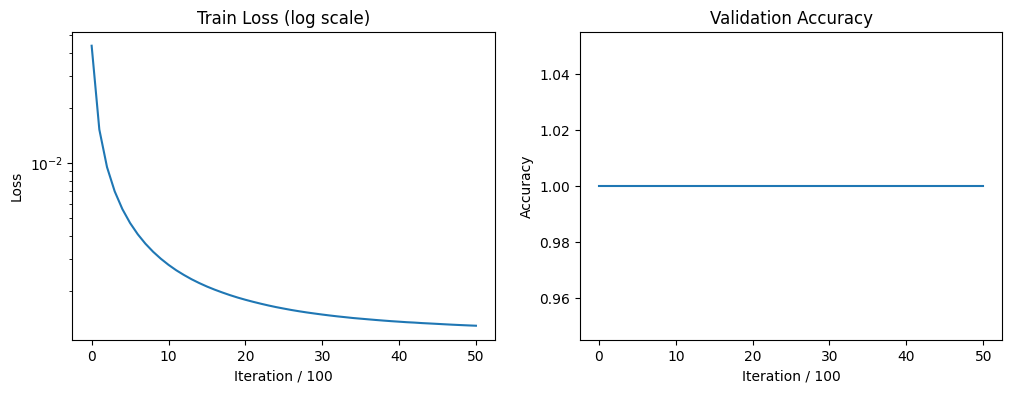

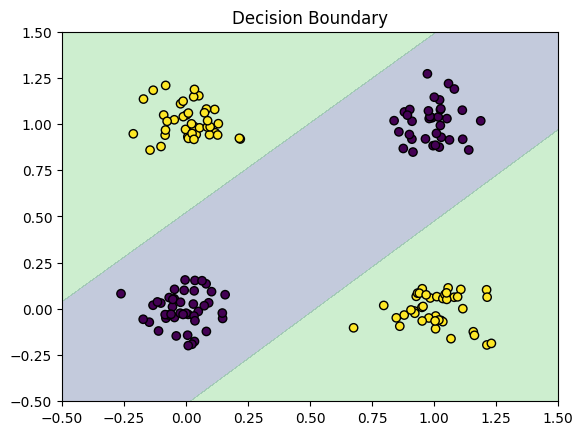

In [ ]:
# === 1-4: 시각화 및 평가 ===
'''
목적: 학습된 XORNet의 Loss 및 Accuracy를 시각화하고 Decision Boundary를 그래픽으로 표현합니다.

요구사항:

Loss와 Accuracy의 epoch에 따른 변화를 그래프로 시각화합니다.

Decision Boundary를 0.5를 기준으로 Grid 데이터를 통해 시각화합니다.
'''

# 1) 학습 곡선
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history['loss'])
plt.yscale('log')
plt.title("Train Loss (log scale)")
plt.xlabel("Iteration / 100")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history['val_acc'])
plt.title("Validation Accuracy")
plt.xlabel("Iteration / 100")
plt.ylabel("Accuracy")
plt.show()

# 2) 결정 경계 시각화
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                     np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

preds_grid = model.forward(grid)
Z = preds_grid.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, levels=[-0.1,0.5,1.1])
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolor='k')
plt.title("Decision Boundary")
plt.show()

---
# Q2. Logistic Regression

In [ ]:
# 2-1: 라이브러리 및 데이터 전처리
'''
목적:

Iris 데이터를 이진 분류 문제로 변형하고, 학습을 위한 전처리 작업을 수행합니다.

상세 요구사항:

Iris 데이터셋에서 클래스 0과 클래스 1 데이터만 추출하여 사용합니다.

데이터 표준화(Standardization)를 수행합니다.

다항식 특성 확장(Polynomial feature expansion)을 수행합니다. (degree=2)

데이터셋을 train/validation으로 70:30 비율로 분할합니다.
'''
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from itertools import combinations_with_replacement

def load_preprocess_data(degree=2):
    """
    - Iris 데이터(이진 분류: 클래스 0 vs 1)
    - 표준화 및 다항식 특성 확장 (degree까지)
    - train/val 70/30 분할 반환
    """
    iris = datasets.load_iris()
    X = iris.data
    y = iris.target

    # Filter classes 0 and 1
    mask = y < 2
    X = X[mask]
    y = y[mask]

    # Standardize
    mu, sigma = X.mean(axis=0), X.std(axis=0)
    Xs = (X - mu) / sigma

    # Polynomial feature expansion
    n, d = Xs.shape
    features = [np.ones(n)]
    for deg in range(1, degree+1):
        for comb in combinations_with_replacement(range(d), deg):
            feat = np.prod(Xs[:, comb], axis=1)
            features.append(feat)
    X_poly = np.vstack(features).T

    return train_test_split(X_poly, y, test_size=0.3, random_state=0)

In [ ]:
# 2-2: 모델 클래스 정의
'''
목적:

Logistic Regression 모델을 클래스 형태로 구현하여 모델을 명확하게 구조화합니다.

상세 요구사항:

클래스명: LogisticRegression

클래스 내 구현할 메서드:

__init__: 모델의 파라미터(가중치, 편향)를 초기화합니다.

forward: 입력 데이터를 받아 순전파 계산 (sigmoid를 이용한 확률값 계산)을 수행합니다.

backward: 손실 함수의 기울기(gradient)를 역전파로 계산합니다.

update: 계산된 gradient를 이용하여 파라미터를 업데이트합니다.
'''
class LogisticRegressionNewton:
    def __init__(self, reg_lambda=1.0, line_search=True):
        """
        - reg_lambda: L2 정규화 강도
        - line_search: True이면 backtracking line search 적용
        """
        self.reg = reg_lambda
        self.line_search = line_search
        self.w = None
        self.loss_history = []

    def fit(self, X, y, num_iter=50, tol=1e-6):
        """
        - 뉴턴법 최적화 구현
        - 매 이터레이션마다 loss 기록 (self.loss_history)
        - tol 기준으로 조기 종료
        """
        n, d = X.shape
        self.w = np.zeros(d)
        self.loss_history = []

        for it in range(num_iter):
            # Linear response & prob
            z = X.dot(self.w)
            p = 1.0 / (1.0 + np.exp(-np.clip(z, -15, 15)))

            # Loss (Cross-Entropy + L2)
            loss = -np.mean(y * np.log(p + 1e-8) + (1 - y) * np.log(1 - p + 1e-8))
            loss += 0.5 * self.reg * np.dot(self.w[1:], self.w[1:])
            self.loss_history.append(loss)

            # Gradient & Hessian
            grad = X.T.dot(p - y) / n
            grad[1:] += self.reg * self.w[1:]

            W = np.diag(p * (1 - p))
            H = (X.T.dot(W).dot(X)) / n
            H[1:, 1:] += self.reg * np.eye(d - 1)

            # Newton step
            delta = np.linalg.solve(H, grad)

            # Backtracking line search
            lr = 1.0
            if self.line_search:
                for _ in range(10):
                    w_new = self.w - lr * delta
                    z_new = X.dot(w_new)
                    p_new = 1.0 / (1.0 + np.exp(-np.clip(z_new, -15, 15)))
                    loss_new = -np.mean(y * np.log(p_new + 1e-8) + (1 - y) * np.log(1 - p_new + 1e-8))
                    loss_new += 0.5 * self.reg * np.dot(w_new[1:], w_new[1:])
                    if loss_new < loss:
                        break
                    lr *= 0.5

            # Update weights
            self.w -= lr * delta

            # Convergence check
            if np.linalg.norm(grad) < tol:
                print(f"Converged at iteration {it}")
                break

    def predict_proba(self, X):
        z = X.dot(self.w)
        return 1.0 / (1.0 + np.exp(-np.clip(z, -15, 15)))

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

In [ ]:
# 2-3: 모델 학습
'''
목적:

정의된 Logistic Regression 모델을 실제 데이터에 학습시킵니다.

상세 요구사항:

Train Acc, Val Acc를 출력합니다.
'''
# 데이터 준비
X_train, X_val, y_train, y_val = load_preprocess_data(degree=2)

# 모델 생성 및 학습
model = LogisticRegressionNewton(reg_lambda=1.0, line_search=True)
model.fit(X_train, y_train)

print("Train Acc:", np.mean(model.predict(X_train) == y_train))
print("Val Acc:  ", np.mean(model.predict(X_val) == y_val))

Converged at iteration 3
Train Acc: 1.0
Val Acc:   1.0


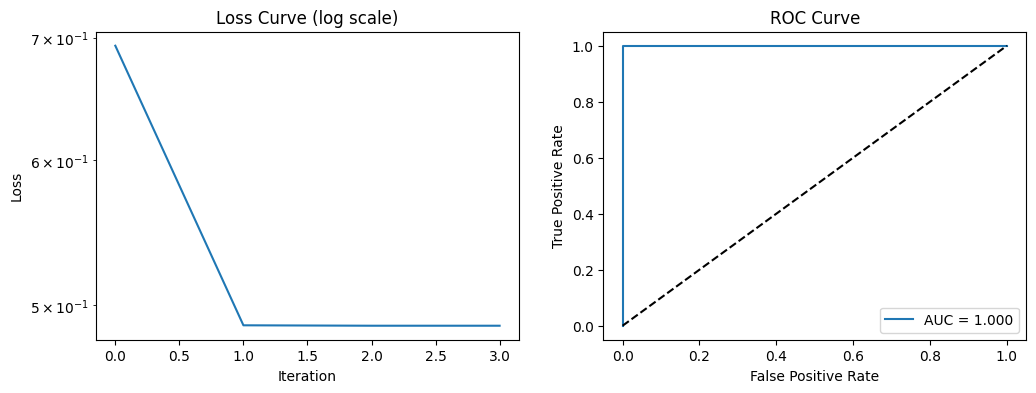

In [ ]:
# 2-4: 시각화 및 평가
'''
목적:

모델의 학습 과정 중 손실(Loss)의 변화와 성능 평가를 위한 ROC Curve를 시각화합니다.

상세 요구사항:

Loss Curve를 iteration에 따라 시각화합니다. (Log scale)

ROC Curve를 시각화하고, ROC Curve의 면적을 나타내는 AUC(Area Under Curve) 값을 계산하여 그래프에 표시합니다.
'''
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 4))

# 1) Loss Curve
plt.subplot(1, 2, 1)
plt.plot(model.loss_history)
plt.yscale('log')
plt.title("Loss Curve (log scale)")
plt.xlabel("Iteration")
plt.ylabel("Loss")

# 2) ROC Curve
plt.subplot(1, 2, 2)
y_score = model.predict_proba(X_val)
fpr, tpr, _ = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

---
# Q3. Deep Autoencoder from Scratch (NumPy + Momentum)

In [ ]:
# === 3-1: 라이브러리 및 데이터 로드 ===
'''
목적:

MNIST 데이터를 로드하고 전처리하여, Autoencoder 학습을 위한 입력 데이터를 준비합니다.

상세 요구사항:

MNIST 데이터셋을 로드합니다. (keras 라이브러리 사용)

전체 MNIST 데이터(train, test)를 합쳐서 사용합니다.

모든 픽셀 값을 [0, 255]에서 [0, 1]로 정규화(normalize)합니다.

데이터는 flatten (784차원) 하여 사용합니다. (28x28 이미지를 784차원의 벡터로)

최종적으로 훈련 데이터로 20,000개의 샘플만 추출하여 사용합니다.
'''
import numpy as np
import matplotlib.pyplot as plt

# MNIST 로드 (keras 사용)
from tensorflow.keras.datasets import mnist

(X_train_full, _), (X_test_full, _) = mnist.load_data()
X_full = np.concatenate([X_train_full, X_test_full], axis=0).astype(np.float32) / 255.0
X_full = X_full.reshape(-1, 784)

# 훈련 전용으로 20000개만 사용
np.random.seed(42)
X_train = X_full[:20000]

print(f"Training samples: {X_train.shape[0]}, dimension: {X_train.shape[1]}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 20000, dimension: 784


In [ ]:
class NumpyAutoencoder:
    def __init__(self, input_dim, hidden_dims, lr=1e-3, momentum=0.9):
        self.lr = lr
        self.momentum = momentum

        # Encoder parameters
        self.W_enc = []
        self.b_enc = []
        in_dim = input_dim
        for h in hidden_dims:
            # He initialization
            W = np.random.randn(in_dim, h) * np.sqrt(2.0 / in_dim)
            b = np.zeros((1, h))
            self.W_enc.append(W)
            self.b_enc.append(b)
            in_dim = h

        # Decoder parameters (mirror)
        hidden_dims_rev = hidden_dims[::-1] + [input_dim]
        self.W_dec = []
        self.b_dec = []
        in_dim = hidden_dims[-1]
        for h in hidden_dims_rev:
            # He initialization
            W = np.random.randn(in_dim, h) * np.sqrt(2.0 / in_dim)
            b = np.zeros((1, h))
            self.W_dec.append(W)
            self.b_dec.append(b)
            in_dim = h

        # Velocity for momentum
        self.vW_enc = [np.zeros_like(W) for W in self.W_enc]
        self.vb_enc = [np.zeros_like(b) for b in self.b_enc]
        self.vW_dec = [np.zeros_like(W) for W in self.W_dec]
        self.vb_dec = [np.zeros_like(b) for b in self.b_dec]

    def forward(self, X):
        self.cache = {}
        a = X
        # Encoder
        for i, (W, b) in enumerate(zip(self.W_enc, self.b_enc)):
            z = a.dot(W) + b
            self.cache[f'z_enc{i}'] = z
            a = np.maximum(0, z) # ReLU
            self.cache[f'a_enc{i}'] = a

        # Decoder
        for i, (W, b) in enumerate(zip(self.W_dec, self.b_dec)):
            z = a.dot(W) + b
            self.cache[f'z_dec{i}'] = z
            if i < len(self.W_dec) - 1:
                a = np.maximum(0, z) # ReLU
            else:
                a = z # Linear output
            self.cache[f'a_dec{i}'] = a
        return a

    def compute_loss(self, X, X_recon):
        return np.mean((X_recon - X) ** 2)

    def backward(self, X):
        m = X.shape[0]
        # Reconstruction gradient
        a_dec = self.cache[f'a_dec{len(self.W_dec)-1}']
        da = 2*(a_dec - X) / m

        # Decoder backward
        for i in reversed(range(len(self.W_dec))):
            z = self.cache[f'z_dec{i}']
            if i == len(self.W_dec) - 1:
                dz = da
            else:
                dz = da * (z > 0)

            a_prev = self.cache[f'a_enc{len(self.W_enc)-1}'] if i==0 else self.cache[f'a_dec{i-1}']
            dW = a_prev.T.dot(dz)
            db = np.sum(dz, axis=0, keepdims=True)
            da = dz.dot(self.W_dec[i].T)

            # Momentum update
            self.vW_dec[i] = self.momentum*self.vW_dec[i] - self.lr*dW
            self.W_dec[i] += self.vW_dec[i]
            self.vb_dec[i] = self.momentum*self.vb_dec[i] - self.lr*db
            self.b_dec[i] += self.vb_dec[i]

        # Encoder backward
        for i in reversed(range(len(self.W_enc))):
            z = self.cache[f'z_enc{i}']
            dz = da * (z > 0)
            a_prev = X if i==0 else self.cache[f'a_enc{i-1}']
            dW = a_prev.T.dot(dz)
            db = np.sum(dz, axis=0, keepdims=True)
            da = dz.dot(self.W_enc[i].T)

            # Momentum update
            self.vW_enc[i] = self.momentum*self.vW_enc[i] - self.lr*dW
            self.W_enc[i] += self.vW_enc[i]
            self.vb_enc[i] = self.momentum*self.vb_enc[i] - self.lr*db
            self.b_enc[i] += self.vb_enc[i]

    def fit(self, X, epochs=20, batch_size=128):
        n = X.shape[0]
        history = {'loss': []}
        for ep in range(1, epochs+1):
            perm = np.random.permutation(n)
            for i in range(0, n, batch_size):
                batch_idx = perm[i:i+batch_size]
                X_batch = X[batch_idx]
                X_recon = self.forward(X_batch)
                self.backward(X_batch)

            # epoch loss
            full_recon = self.forward(X)
            loss = self.compute_loss(X, full_recon)
            history['loss'].append(loss)
            print(f"Epoch {ep}/{epochs} - Loss: {loss:.6f}")
        return history

    def reconstruct(self, X):
        return self.forward(X)

In [ ]:
# === 3-3: 모델 학습 ===
ae_model = NumpyAutoencoder(input_dim=784, hidden_dims=[256,64], lr=1e-3, momentum=0.9)
history = ae_model.fit(X_train, epochs=20, batch_size=256)

Epoch 1/20 - Loss: 0.064050
Epoch 2/20 - Loss: 0.063174
Epoch 3/20 - Loss: 0.062595
Epoch 4/20 - Loss: 0.062092
Epoch 5/20 - Loss: 0.061650
Epoch 6/20 - Loss: 0.061297
Epoch 7/20 - Loss: 0.061037
Epoch 8/20 - Loss: 0.060948
Epoch 9/20 - Loss: 0.060962
Epoch 10/20 - Loss: 0.060539
Epoch 11/20 - Loss: 0.060410
Epoch 12/20 - Loss: 0.060585
Epoch 13/20 - Loss: 0.060370
Epoch 14/20 - Loss: 0.060178
Epoch 15/20 - Loss: 0.059848
Epoch 16/20 - Loss: 0.059862
Epoch 17/20 - Loss: 0.059664
Epoch 18/20 - Loss: 0.059852
Epoch 19/20 - Loss: 0.059719
Epoch 20/20 - Loss: 0.059242


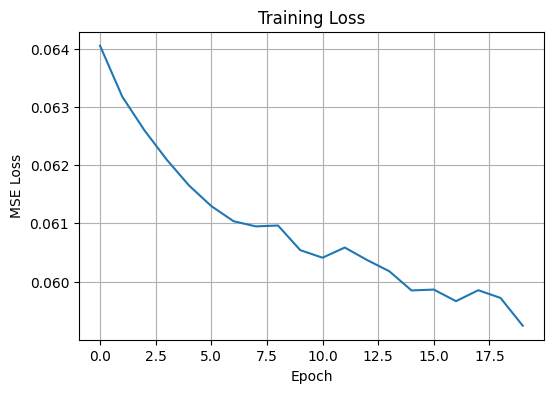

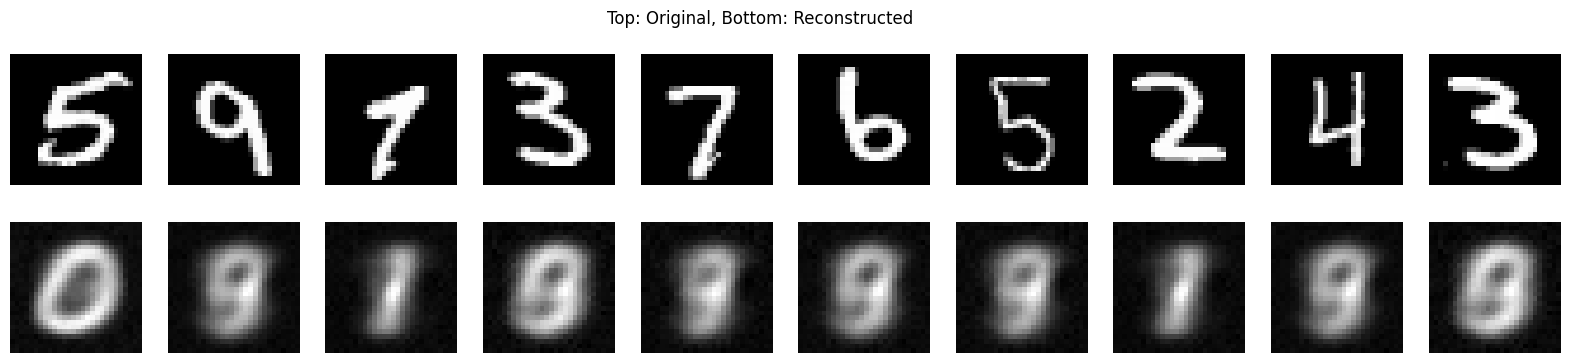

In [ ]:
# === 3-4: 시각화 및 재구성 결과 ===
'''
목적:
학습된 Autoencoder의 복원 성능과 학습 과정(손실)을 시각적으로 확인하여 평가합니다.

요구사항:
손실 곡선 시각화 - Epoch에 따른 MSE Loss 변화 그래프

재구성 결과 시각화 - 원본 MNIST 이미지와 Autoencoder가 재구성한 이미지를 나란히 비교 시각화 (샘플 10개)

추가 세부사항:
손실곡선의 y축은 MSE Loss로 명확히 표기

시각화된 이미지: 상단은 원본 이미지, 하단은 복원된 이미지로 표현
'''
# 손실 곡선
plt.figure(figsize=(6, 4))
plt.plot(history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# 몇 개 샘플 재구성 시각화
# Q2 모델과의 충돌을 방지하기 위해 ae_model 변수를 사용합니다.
n_show = 10
X_vis = X_full[20000:20000+n_show]
recon_vis = ae_model.reconstruct(X_vis)

fig, axes = plt.subplots(2, n_show, figsize=(20,4))
for i in range(n_show):
    axes[0,i].imshow(X_vis[i].reshape(28,28), cmap='gray')
    axes[0,i].axis('off')
    axes[1,i].imshow(recon_vis[i].reshape(28,28), cmap='gray')
    axes[1,i].axis('off')
fig.suptitle("Top: Original, Bottom: Reconstructed")
plt.show()

---
# Q4. Deep MLP from Scratch (NumPy + BatchNorm + Dropout)

In [ ]:
# === 4-1: 라이브러리 및 데이터 준비 ===
'''
목적:
Digits 데이터셋을 활용하여 0~4 숫자 이미지를 분류하는 다중 클래스 분류(Multi-class classification)를 위한 데이터를 준비하고, 필요한 유틸리티 함수를 정의합니다.

요구사항:
Digits 데이터셋에서 클래스 0~4만 추출, 픽셀 값을 [0,1]로 정규화

One-hot Encoding을 수행하여 다중 클래스 분류 준비

Train/Validation 데이터를 80:20으로 분할

Xavier 초기화 함수 (xavier_init) 및 활성화 함수 (ELU)와 미분 함수 (elu_grad)를 유틸리티 함수로 정의하여 준비합니다.
'''
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1) Digits 0-4 필터링, [0,1] 정규화
digits = load_digits()
mask = digits.target < 5
X = digits.data[mask] / 16.0
y = digits.target[mask].reshape(-1,1)

# 2) One-hot 인코딩
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# 3) Train/Val 분할
X_train, X_val, y_train, y_val = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 4) 유틸 함수
def xavier_init(fan_in, fan_out):
    return np.random.randn(fan_in, fan_out) * np.sqrt(2.0/(fan_in+fan_out))

def elu(x, alpha=1.0):
    return np.where(x>0, x, alpha*(np.exp(x)-1))

def elu_grad(x, alpha=1.0):
    return np.where(x>0, 1, alpha*np.exp(x))


In [ ]:
# === 4-2: NumpyMLPAdvanced 클래스 ===
'''
목적:
NumPy를 사용하여 고급 기능을 포함한 다층 퍼셉트론(MLP)을 구현하고, 딥러닝 모델 학습 원리를 학습합니다.

요구사항:
클래스명: NumpyMLPAdvanced

아래 기능을 포함하여 클래스 정의:

파라미터 초기화 (Xavier 초기화)

순전파(forward propagation): ELU 활성화, Batch Normalization, Dropout, 출력층 Softmax

역전파(backward propagation): 역전파를 통한 기울기 계산, Gradient clipping, Batch Normalization 역전파 구현

최적화 방법: Momentum 기반 SGD 및 Adam 최적화 알고리즘 구현

학습 과정(fit): 미니배치 학습, Cosine Annealing 학습률 스케줄링, epoch마다 학습 및 검증 성능 기록

세부 구현 사항:
활성화 함수: ELU 사용

출력층 활성화: Softmax 함수 사용

손실 함수: 교차 엔트로피(Cross Entropy Loss) + L2 정규화

Epoch마다 train/val 손실(loss), 정확도(acc), 기울기 norm, 파라미터 norm 기록

최종 예측 메서드(predict) 정의
'''
import numpy as np

class NumpyMLPAdvanced:
    def __init__(self, layer_sizes, lr=1e-3, reg=1e-4, momentum=0.9,
                 beta1=0.9, beta2=0.999, eps=1e-8, dropout_rate=0.5):
        self.L = len(layer_sizes)-1
        self.layer_sizes = layer_sizes
        self.lr0, self.reg, self.mom = lr, reg, momentum
        self.beta1, self.beta2, self.eps = beta1, beta2, eps
        self.dr = dropout_rate

        # 파라미터 초기화
        self.W = {i: xavier_init(layer_sizes[i], layer_sizes[i+1]) for i in range(self.L)}
        self.b = {i: np.zeros((1, layer_sizes[i+1])) for i in range(self.L)}

        # BatchNorm 파라미터
        self.gamma = {i: np.ones((1,layer_sizes[i+1])) for i in range(self.L-1)}
        self.beta  = {i: np.zeros((1,layer_sizes[i+1])) for i in range(self.L-1)}
        self.running_mean = {i: np.zeros((1,layer_sizes[i+1])) for i in range(self.L-1)}
        self.running_var  = {i: np.ones((1,layer_sizes[i+1]))  for i in range(self.L-1)}

        # Optimizer state
        self.vW  = {i: np.zeros_like(self.W[i]) for i in range(self.L)}
        self.vb  = {i: np.zeros_like(self.b[i]) for i in range(self.L)}
        self.mW  = {i: np.zeros_like(self.W[i]) for i in range(self.L)}
        self.vW_adam = {i: np.zeros_like(self.W[i]) for i in range(self.L)}
        self.mb  = {i: np.zeros_like(self.b[i]) for i in range(self.L)}
        self.vb_adam = {i: np.zeros_like(self.b[i]) for i in range(self.L)}

    def forward(self, X, is_training=True):
        self.cache = {}
        out = X.copy()
        for i in range(self.L):
            Z = out.dot(self.W[i]) + self.b[i]
            self.cache[f'Z{i}'] = Z
            if i < self.L-1:
                # BatchNorm
                if is_training:
                    mu  = Z.mean(axis=0, keepdims=True)
                    var = Z.var(axis=0, keepdims=True) + 1e-5
                    self.running_mean[i] = 0.9*self.running_mean[i] + 0.1*mu
                    self.running_var[i]  = 0.9*self.running_var[i]  + 0.1*var
                    Zn  = (Z - mu) / np.sqrt(var)
                else:
                    mu  = self.running_mean[i]
                    var = self.running_var[i]
                    Zn  = (Z - mu) / np.sqrt(var)
                Zb = self.gamma[i]*Zn + self.beta[i]
                self.cache[f'Zn{i}'], self.cache[f'mu{i}'], self.cache[f'var{i}'] = Zn, mu, var

                # ELU activation
                A = elu(Zb)
                self.cache[f'A{i}'] = A

                # Dropout
                if is_training:
                    mask = (np.random.rand(*A.shape) > self.dr) / (1 - self.dr)
                    A *= mask
                    self.cache[f'mask{i}'] = mask

                out = A
            else:
                # final Softmax
                expZ = np.exp(Z - Z.max(axis=1, keepdims=True))
                out = expZ / expZ.sum(axis=1, keepdims=True)
                self.cache[f'A{i}'] = out

        return out

    def compute_loss_and_grads(self, X, Y):
        m = X.shape[0]
        Y_pred = self.forward(X, is_training=True)
        # Loss
        loss = -np.sum(Y * np.log(Y_pred + 1e-8)) / m
        for i in range(self.L):
            loss += 0.5 * self.reg * np.sum(self.W[i]**2)
        # Backward
        grads = {}
        dA = (Y_pred - Y) / m
        for i in reversed(range(self.L)):
            A_prev = X if i==0 else self.cache[f'A{i-1}']
            grads[f'dW{i}'] = A_prev.T.dot(dA) + self.reg * self.W[i]
            grads[f'db{i}'] = np.sum(dA, axis=0, keepdims=True)
            if i>0:
                dZ = dA.dot(self.W[i].T)
                if f'mask{i-1}' in self.cache:
                    dZ *= self.cache[f'mask{i-1}']
                Zb = self.cache[f'Zn{i-1}']*np.sqrt(self.cache[f'var{i-1}']) + self.cache[f'mu{i-1}']
                dZ = dZ * elu_grad(Zb)
                Zn, mu, var = (self.cache[f'Zn{i-1}'],
                               self.cache[f'mu{i-1}'],
                               self.cache[f'var{i-1}'])
                dgamma = np.sum(dZ * Zn, axis=0, keepdims=True)
                dbeta  = np.sum(dZ,      axis=0, keepdims=True)
                grads[f'dgamma{i-1}'], grads[f'dbeta{i-1}'] = dgamma, dbeta
                dZn = dZ * self.gamma[i-1]
                dvar = np.sum(dZn*(self.cache[f'Z{i-1}']-mu)*-0.5*(var**-1.5), axis=0, keepdims=True)
                dmu  = (np.sum(dZn*-1/np.sqrt(var),axis=0,keepdims=True)
                        + dvar*np.mean(-2*(self.cache[f'Z{i-1}']-mu),axis=0,keepdims=True))
                dA = dZn/np.sqrt(var) + dvar*2*(self.cache[f'Z{i-1}']-mu)/m + dmu/m
        # Gradient clipping
        total_norm = np.sqrt(sum(np.sum(grads[f'dW{i}']**2) for i in range(self.L)))
        clip_coef = 5.0/(total_norm+1e-6) if total_norm>5.0 else 1.0
        for i in range(self.L):
            grads[f'dW{i}'] *= clip_coef
            grads[f'db{i}'] *= clip_coef
        return loss, grads, total_norm

    def update_params(self, grads, t):
        for i in range(self.L):
            # Momentum SGD
            self.vW[i] = self.mom*self.vW[i] - self.lr0*grads[f'dW{i}']
            self.W[i] += self.vW[i]
            self.vb[i] = self.mom*self.vb[i] - self.lr0*grads[f'db{i}']
            self.b[i] += self.vb[i]
            # Adam update
            self.mW[i] = self.beta1*self.mW[i] + (1-self.beta1)*grads[f'dW{i}']
            self.vW_adam[i] = self.beta2*self.vW_adam[i] + (1-self.beta2)*(grads[f'dW{i}']**2)
            m_hat = self.mW[i]/(1-self.beta1**t)
            v_hat = self.vW_adam[i]/(1-self.beta2**t)
            self.W[i] -= self.lr0 * m_hat/(np.sqrt(v_hat)+self.eps)
            # Bias Adam
            self.mb[i] = self.beta1*self.mb[i] + (1-self.beta1)*grads[f'db{i}']
            self.vb_adam[i] = self.beta2*self.vb_adam[i] + (1-self.beta2)*(grads[f'db{i}']**2)
            mb_hat = self.mb[i]/(1-self.beta1**t)
            vb_hat = self.vb_adam[i]/(1-self.beta2**t)
            self.b[i] -= self.lr0 * mb_hat/(np.sqrt(vb_hat)+self.eps)

    def fit(self, X_train, Y_train, X_val, Y_val, epochs=30, batch_size=64):
        n, _ = X_train.shape
        history = {'train_loss':[], 'train_acc':[], 'val_loss':[],
                   'val_acc':[], 'grad_norm':[], 'param_norm':[]}
        t = 1
        for ep in range(epochs):
            # Cosine Annealing Learning Rate
            self.lr0 = 1e-3 * 0.5 * (1 + np.cos(np.pi * ep / epochs))

            perm = np.random.permutation(n)
            for i in range(0, n, batch_size):
                batch_idx = perm[i:i+batch_size]
                X_batch = X_train[batch_idx]
                Y_batch = Y_train[batch_idx]
                loss, grads, gnorm = self.compute_loss_and_grads(X_batch, Y_batch)
                self.update_params(grads, t)
                t += 1

            pnorm = np.sqrt(sum(np.sum(self.W[i]**2) for i in range(self.L)))

            # Epoch metrics
            Yp_tr = np.argmax(self.forward(X_train, False),axis=1)
            Yt_tr = np.argmax(Y_train,axis=1)
            Yp_val= np.argmax(self.forward(X_val, False),axis=1)
            Yt_val= np.argmax(Y_val,axis=1)
            history['train_loss'].append(loss)
            history['train_acc'].append((Yp_tr==Yt_tr).mean())
            vloss,_ ,_ = self.compute_loss_and_grads(X_val, Y_val)
            history['val_loss'].append(vloss)
            history['val_acc'].append((Yp_val==Yt_val).mean())
            history['grad_norm'].append(gnorm)
            history['param_norm'].append(pnorm)
            print(f"Epoch {ep+1}: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")
        return history

    def predict(self, X):
        Y_pred = self.forward(X, is_training=False)
        return np.argmax(Y_pred, axis=1)


In [ ]:
# === 4-3: 학습 실행 및 로그 ===
# - 모델 인스턴스 생성 (구조: 64 -> 256 -> 128 -> 5)
# - fit 호출
# - 최종 train/val accuracy 출력

mlp_model = NumpyMLPAdvanced(
    layer_sizes=[64, 256, 128, 5],
    lr=1e-3,
    reg=1e-4,
    momentum=0.9,
    dropout_rate=0.5
)

history = mlp_model.fit(
    X_train, y_train,
    X_val, y_val,
    epochs=20,
    batch_size=128
)

final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
print(f"\nFinal Train Accuracy: {final_train_acc:.4f}")
print(f"Final Val Accuracy: {final_val_acc:.4f}")


Epoch 1: train_acc=0.9292, val_acc=0.9613
Epoch 2: train_acc=0.9625, val_acc=0.9890
Epoch 3: train_acc=0.9736, val_acc=0.9890
Epoch 4: train_acc=0.9847, val_acc=0.9834
Epoch 5: train_acc=0.9903, val_acc=0.9890
Epoch 6: train_acc=0.9931, val_acc=0.9890
Epoch 7: train_acc=0.9944, val_acc=0.9890
Epoch 8: train_acc=0.9958, val_acc=0.9890
Epoch 9: train_acc=0.9958, val_acc=0.9890
Epoch 10: train_acc=0.9958, val_acc=0.9890
Epoch 11: train_acc=0.9958, val_acc=0.9890
Epoch 12: train_acc=0.9958, val_acc=0.9890
Epoch 13: train_acc=0.9958, val_acc=0.9834
Epoch 14: train_acc=0.9958, val_acc=0.9834
Epoch 15: train_acc=0.9958, val_acc=0.9834
Epoch 16: train_acc=0.9958, val_acc=0.9834
Epoch 17: train_acc=0.9958, val_acc=0.9834
Epoch 18: train_acc=0.9958, val_acc=0.9834
Epoch 19: train_acc=0.9958, val_acc=0.9834
Epoch 20: train_acc=0.9958, val_acc=0.9834

Final Train Accuracy: 0.9958
Final Val Accuracy: 0.9834


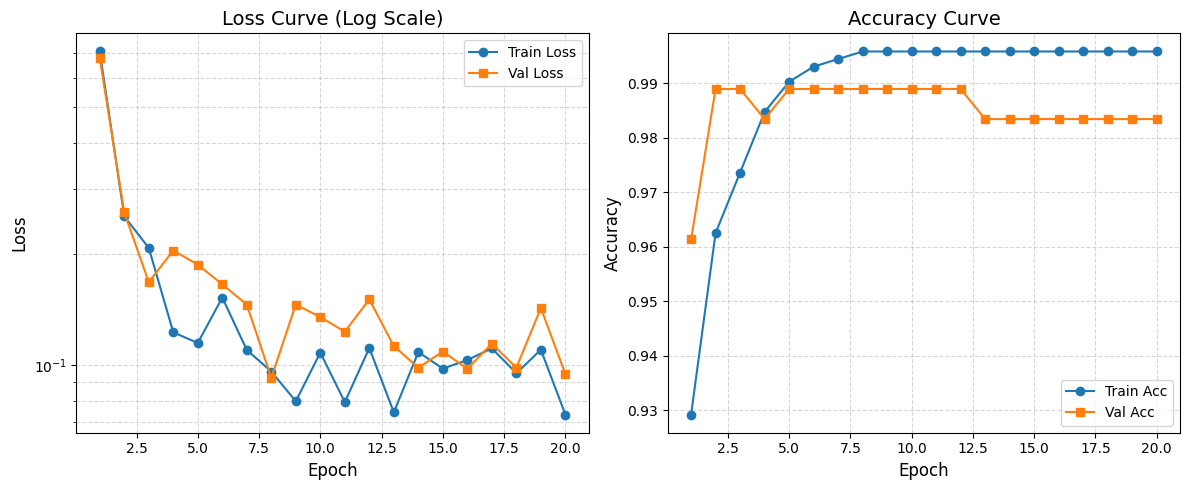

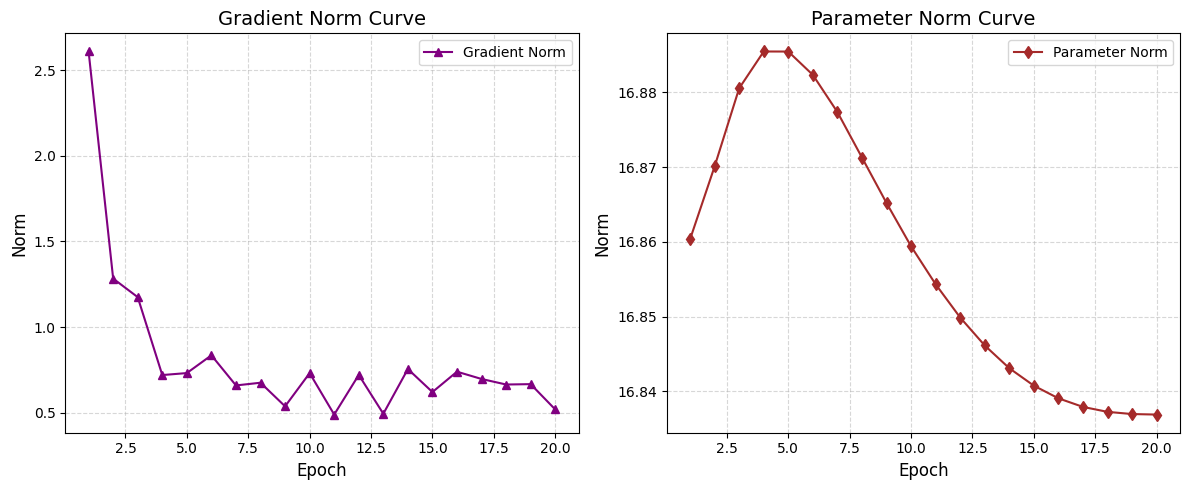

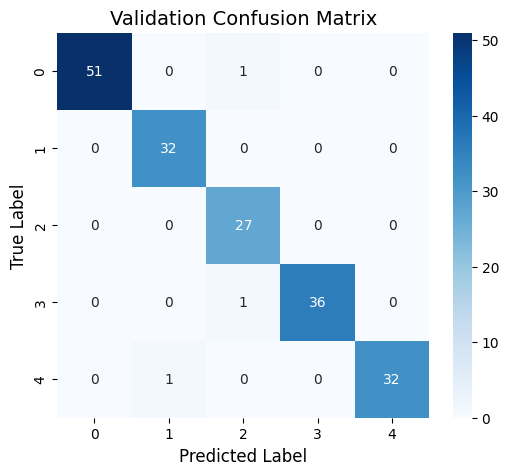

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# 1) Loss & Accuracy Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', marker='o')
plt.plot(range(1, len(history['val_loss']) + 1), history['val_loss'], label='Val Loss', marker='s')
plt.yscale('log')
plt.title('Loss Curve (Log Scale)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['train_acc']) + 1), history['train_acc'], label='Train Acc', marker='o')
plt.plot(range(1, len(history['val_acc']) + 1), history['val_acc'], label='Val Acc', marker='s')
plt.title('Accuracy Curve', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# 2) Grad Norm & Param Norm
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['grad_norm']) + 1), history['grad_norm'], color='purple', marker='^', label='Gradient Norm')
plt.title('Gradient Norm Curve', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Norm', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['param_norm']) + 1), history['param_norm'], color='brown', marker='d', label='Parameter Norm')
plt.title('Parameter Norm Curve', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Norm', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# 3) Confusion Matrix on Validation Set
y_val_pred = mlp_model.predict(X_val)
y_val_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Validation Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [ ]:
#####################
#   수정하지 마세요 / sanity_code를 사용하기 위한 코드입니다.
#####################

import importlib.util
import sys
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np
import torch
import torch.nn as nn

file_path = "/content/drive/MyDrive/ColabNotebooks/10week/__pycache__/sanity_utils.cpython-311.pyc"
# file_path = "/content/drive/MyDrive/your_work_path/__pycache__/sanity_utils.cpython-311.pyc"
#__pycache__/sanity_utils.cpython-311.pyc 이 루트가 코랩 상에서는 보이지 않을 수 있으니 앞에 경로를 수정하여 사용하시면 됩니다.
# 자신이 작업하는 ipynb 파일이 있는 곳에 __pycache__ 폴더를 넣어주시면 됩니다. (pycache 폴더 안에는 보안화된 pyc 파일 존재)

module_name = "sanity_utils"

spec = importlib.util.spec_from_file_location(module_name, file_path)

sanity_utils = importlib.util.module_from_spec(spec)
sys.modules[module_name] = sanity_utils
spec.loader.exec_module(sanity_utils)

sync_rnn_weights = sanity_utils.sync_rnn_weights
rnn_forward_sanity_check = sanity_utils.rnn_forward_sanity_check
rnn_backward_sanity_check = sanity_utils.rnn_backward_sanity_check
sync_lstm_weights = sanity_utils.sync_lstm_weights
lstm_forward_sanity_check = sanity_utils.lstm_forward_sanity_check
lstm_backward_sanity_check = sanity_utils.lstm_backward_sanity_check

print("sanity_utils module has been successfully loaded.")

ImportError: bad magic number in 'sanity_utils': b'\xa7\r\r\n'

In [ ]:
### Google Colab 파이썬 버전을 3.11로 다운그레이드하는 스크립트
!sudo apt-get update -y
!sudo apt-get install python3.11 python3.11-dev python3.11-distutils -y

# 파이썬 대안(alternative) 우선순위 설정
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.11 1
!sudo update-alternatives --set python3 /usr/bin/python3.11

# pip 재설치
!curl -sS https://bootstrap.pypa.io/get-pip.py | python3

# 필수 라이브러리 및 과제에 사용 중인 라이브러리 재설치
!python3 -m pip install ipykernel scikit-learn numpy matplotlib tensorflow torch gensim seaborn

# 커널 재시작 유도
import os
print("\n파이썬 3.11 변경 및 라이브러리 설치가 완료되었습니다. 변경을 적용하기 위해 런타임을 재시작합니다...")
os.kill(os.getpid(), 9)

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:7 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:10 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [1,318 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:12 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [1,943 kB]
Get:13 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [

In [ ]:
### Python 3.11 커널을 주피터에 등록
import sys
import os
import shutil

# 시스템 전체에서 python3.11 실행 경로 탐색
python_path = shutil.which("python3.11") or shutil.which("python3")

# 혹은 직접적인 파일 존재 여부 확인
if not python_path or not os.path.exists(python_path):
    for path in ["/usr/bin/python3.11", "/usr/local/bin/python3.11", "/usr/bin/python3"]:
        if os.path.exists(path):
            python_path = path
            break

if python_path:
    print(f"감지된 파이썬 경로: {python_path}")
    !{python_path} -m pip install ipykernel
    !{python_path} -m ipykernel install --user --name=python3.11 --display-name "Python 3.11"
    print(f"\n주피터 커널({python_path}) 등록 완료! 페이지를 새로고침(F5) 하신 후, 우측 상단의 런타임 설정이나 메뉴에서 'Python 3.11' 커널을 선택하여 실행해 주세요.")
else:
    print("오류: python3.11을 시스템에서 찾을 수 없습니다. python3.11 설치 단계를 다시 확인해 주세요.")

감지된 파이썬 경로: /usr/bin/python3


# Q5~6: RNN

In [ ]:
# RNN from Scratch 과제 (Numpy만 사용)

"""
문제 7~8. RNN Forward 및 Backward 구현

설명:
이 문제에서는 순환신경망(RNN)의 forward 및 backward 과정을 numpy만 사용하여 직접 구현합니다.
주어진 입력 시퀀스 x_seq와 정답 y_seq를 기반으로 시계열 예측 문제를 풀기 위한 RNN 모델을 완성해야 합니다.

1. forward 함수:
다음 순서로 시퀀스를 처리하여 시간별 hidden state 및 출력 확률을 계산합니다.
    - 각 시점 t에 대해: h_t = tanh(Wx * x_t + Wh * h_{t-1} + bh)
    - 각 시점 t에 대해: y_hat_t = softmax(Wy * h_t + by)
    - 정답 y_seq와 비교하여 전체 cross-entropy loss를 저장하세요.
    - 각 시점의 hidden state는 self.hs 리스트에 저장합니다.

2. backward 함수:
forward에서 저장한 중간 결과를 기반으로 역전파를 수행하여 다음 기울기를 계산합니다.
    - dWy, dby: 출력 계층의 가중치 및 편향 기울기
    - dWx, dWh, dbh: RNN 본체의 가중치 및 편향 기울기
    - BPTT (Backpropagation Through Time)를 적용해야 하며, 시간 축을 따라 역전파해야 합니다.

요구사항:
- 모든 연산은 numpy만 사용해야 하며, PyTorch 사용은 금지됩니다.
- cross-entropy loss 계산 시 softmax를 활용하세요.
- forward에서는 hs (hidden states)를 저장해야 합니다.
- backward에서는 chain rule에 따라 각 가중치의 기울기를 정확히 계산하세요.

평가 기준:
- rnn_forward_sanity_check()를 통과하면 forward 구현은 +1점
- rnn_backward_sanity_check()를 통과하면 backward 구현은 +1점
"""

##########################################
# RNN 구현: forward / backward
##########################################
class RNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.Wx = np.random.randn(hidden_size, input_size) * np.sqrt(1. / input_size)
        self.Wh = np.random.randn(hidden_size, hidden_size) * np.sqrt(1. / hidden_size)
        self.bh = np.zeros((hidden_size, 1))

        self.Wy = np.random.randn(output_size, hidden_size) * np.sqrt(1. / hidden_size)
        self.by = np.zeros((output_size, 1))

        self.dWx = np.zeros_like(self.Wx)
        self.dWh = np.zeros_like(self.Wh)
        self.dbh = np.zeros_like(self.bh)
        self.dWy = np.zeros_like(self.Wy)
        self.dby = np.zeros_like(self.by)

    def softmax(self, x):
        e = np.exp(x - np.max(x))
        return e / np.sum(e, axis=0, keepdims=True)

    def forward(self, x_seq, y_seq):
        # TODO
        pass

    def backward(self):
        # TODO
        pass

In [ ]:
#########################################
# 테스트 코드 (수정하지 마세요)
#########################################

# 테스트 데이터
input_size = 4
hidden_size = 3
output_size = 2
seq_len = 5

x_seq = [np.random.randn(input_size) for _ in range(seq_len)]
y_seq = [np.random.randint(0, output_size) for _ in range(seq_len)]

# 모델 생성
rnn_np = RNN(input_size, hidden_size, output_size)
rnn_pt = nn.RNN(input_size, hidden_size, nonlinearity="tanh", batch_first=False).double()

# 가중치 동기화
sync_rnn_weights(rnn_np, rnn_pt)

##########################
# Assignment 7 RNN Forward 구현
##########################
rnn_forward_sanity_check(rnn_np, rnn_pt, x_seq, y_seq)

##########################
# Assignment 8 RNN Backward 구현
##########################
rnn_backward_sanity_check(rnn_np, rnn_pt, x_seq, y_seq)

'''
RNN Forward Sanity Check: Pass
Wy: Pass (Relative diff: 0.000000)
by: Pass (Relative diff: 0.000000)
RNN Backward Sanity Check: Pass
'''

RNN Forward Sanity Check: Pass
Wy: Pass (Relative diff: 0.000000)
by: Pass (Relative diff: 0.000000)
RNN Backward Sanity Check: Pass


'\nRNN Forward Sanity Check: Pass\nWy: Pass (Relative diff: 0.000000)\nby: Pass (Relative diff: 0.000000)\nRNN Backward Sanity Check: Pass\n'

# Q7~8: LSTM

In [ ]:
# LSTM from Scratch 과제 (Numpy만 사용)

"""
문제 9~10. LSTM Forward 및 Backward 구현

설명:
이 과제에서는 순환신경망의 확장 구조인 LSTM(Long Short-Term Memory)을 numpy로 직접 구현합니다.
PyTorch 모델과의 결과 비교를 통해 정확성을 검증합니다.

1. forward 함수:
입력 시퀀스를 받아 아래의 연산 순서에 따라 은닉 상태와 출력값을 계산합니다.
각 시간 t에서의 연산은 다음과 같습니다:

    - i_t = sigmoid(x_t @ W_xi + h_{t-1} @ W_hi + b_i)   # input gate
    - f_t = sigmoid(x_t @ W_xf + h_{t-1} @ W_hf + b_f)   # forget gate
    - g_t = tanh(x_t @ W_xc + h_{t-1} @ W_hc + b_c)      # cell candidate
    - o_t = sigmoid(x_t @ W_xo + h_{t-1} @ W_ho + b_o)   # output gate
    - c_t = f_t * c_{t-1} + i_t * g_t                    # cell state
    - h_t = o_t * tanh(c_t)                              # hidden state
    - y_t = h_t @ W_hy + b_y                             # output

전체 시퀀스에 대해 y, h, c를 계산하고, 중간 결과(i, f, g, o 등)를 저장해둡니다.

2. backward 함수:
forward에서 저장한 중간값을 활용해 chain rule로 역전파를 수행합니다.
출력의 그래디언트(dout)가 주어졌을 때, 다음을 계산해야 합니다:

    - dx: 입력 x에 대한 그래디언트
    - dh_prev: 초기 은닉 상태에 대한 그래디언트
    - dc_prev: 초기 셀 상태에 대한 그래디언트
    - 각 가중치 및 편향에 대한 그래디언트: dW_xi, dW_hi, db_i 등

시간 역순으로 반복하며, 각 게이트의 미분 식(sigmoid, tanh의 도함수 포함)을 적용해야 합니다.

요구사항:
- 모든 연산은 numpy로만 구현해야 하며, PyTorch 사용은 불가
- forward에서는 전체 시퀀스의 중간 값들을 self 변수에 저장
- backward에서는 각 가중치와 입력, 초기 상태에 대한 정확한 기울기를 계산

평가 기준:
- lstm_forward_sanity_check() 통과 시 forward 구현 +1점
- lstm_backward_sanity_check() 통과 시 backward 구현 +1점
"""

##########################################
# 활성화 함수
##########################################
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -15, 15)))

def dsigmoid(y):
    return y * (1 - y)

def dtanh(y):
    return 1 - y**2


##########################################
# NumPy 기반 LSTM 클래스
##########################################
class LSTM:
    def __init__(self, input_size, hidden_size, output_size):
        k = 1.0 / np.sqrt(hidden_size)

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.W_xi = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_hi = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b_i = np.zeros(hidden_size)

        self.W_xf = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_hf = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b_f = np.zeros(hidden_size)

        self.W_xc = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_hc = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b_c = np.zeros(hidden_size)

        self.W_xo = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_ho = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b_o = np.zeros(hidden_size)

        self.W_hy = np.random.uniform(-k, k, (hidden_size, output_size))
        self.b_y = np.zeros(output_size)

        self.x = None
        self.h = None
        self.c = None
        self.i = None
        self.f = None
        self.g = None
        self.o = None
        self.y = None

    def forward(self, x, h_prev=None, c_prev=None):
        # TODO
        pass

    def backward(self, dout):
        # TODO
        pass


##########################################
# PyTorch 구현 (수정하지 마세요)
##########################################
class PyTorchLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PyTorchLSTM, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden=None):
        output, (h_n, c_n) = self.lstm(x, hidden)
        batch_size, seq_length, _ = output.shape
        output_reshaped = output.contiguous().view(-1, self.hidden_size)
        fc_output = self.fc(output_reshaped)
        y = fc_output.view(batch_size, seq_length, self.output_size)
        return y, (h_n, c_n)

In [ ]:
##########################################
# 입력 데이터 준비 (수정하지 마세요)
##########################################
input_size = 10
hidden_size = 20
output_size = 5
batch_size = 3
sequence_length = 4
rtol = 1e-3
atol = 1e-3

lstm_np = LSTM(input_size, hidden_size, output_size)
lstm_pt = PyTorchLSTM(input_size, hidden_size, output_size).double()
sync_lstm_weights(lstm_np, lstm_pt)

x = np.random.randn(batch_size, sequence_length, input_size)

##########################################
# Assignment 9 LSTM Forward 구현
##########################################
forward_result, (y_np, h_np, c_np), (y_pt, h_pt, c_pt) = lstm_forward_sanity_check(lstm_np, lstm_pt, x, None, None, rtol, atol)

##########################################
# Assignment 10 LSTM Backward 구현
##########################################
dout = np.random.randn(*y_np.shape)
backward_result, np_grads, pt_grads = lstm_backward_sanity_check(lstm_np, lstm_pt, x, dout, None, None, rtol, atol)

'''
LSTM Forward Sanity Check: Pass
LSTM Backward Sanity Check: Pass
'''

LSTM Forward Sanity Check: Pass
LSTM Backward Sanity Check: Pass


'\nLSTM Forward Sanity Check: Pass\nLSTM Backward Sanity Check: Pass\n'

# Q9:
Word2Vec으로 직접 단어 학습을 거치고 유사어를 찾습니다.
PyTorch를 이용해 Word2Vec의 Skip-Gram 모델을 직접 구현합니다.  
단어를 임베딩한 후, 학습된 임베딩을 통해 유사한 단어를 찾아봅니다.
- 학습 데이터는 간단한 샘플 문장들로 구성되어 있습니다.
- Skip-Gram 구조를 직접 구성하여 임베딩을 학습합니다.
- 학습 후 특정 단어와 가장 유사한 단어를 코사인 유사도로 검색합니다.


In [ ]:
# Import Requirements
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
# 1. 샘플 문장 준비
corpus = [
    "the king loves the queen",
    "the queen loves the king",
    "the king hates the man",
    "the queen hates the woman",
    "the man loves the woman",
    "the woman loves the man",
]

# 2. 단어 사전 구축
words = set(" ".join(corpus).split())
word2idx = {w: idx for idx, w in enumerate(words)}
idx2word = {idx: w for w, idx in word2idx.items()}
vocab_size = len(words)

In [ ]:
# 3. 데이터셋 생성
context_window = 2
pairs = []
for sentence in corpus:
    """
    TODO
    """

In [ ]:
# 4. Dataset, DataLoader 정의
class Word2VecDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]

dataset = Word2VecDataset(pairs)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

ValueError: num_samples should be a positive integer value, but got num_samples=0

In [ ]:
# 5. Word2Vec 모델 정의
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, embed_size):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, embed_size)
        self.out_embed = nn.Embedding(vocab_size, embed_size)

    def forward(self, center_words, context_words):
        """
        TODO
        """
        return scores

    def get_embeddings(self):
        return self.in_embed.weight.data.cpu()

embed_size = 10
model = Word2Vec(vocab_size, embed_size)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
# 6. 학습
for epoch in range(100):
    """
    TODO
    """

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

NameError: name 'dataloader' is not defined

In [ ]:
# 7. 특정 단어와 가장 유사한 단어 찾기
def most_similar(word, top_n=3):
    if word not in word2idx:
        print("단어를 찾을 수 없습니다.")
        return
    idx = word2idx[word]

    """
    TODO
    """

    print(f"\n'{word}'와 가장 비슷한 단어들:")
    for i in sorted_indices[1:top_n+1]:
        print(f"{idx2word[i]} ({sims[i]:.4f})")

most_similar("king")
most_similar("queen")


'king'와 가장 비슷한 단어들:
man (0.5269)
queen (0.3849)
the (0.2915)

'queen'와 가장 비슷한 단어들:
man (0.5935)
hates (0.4230)
king (0.3849)


2. 사전학습된 Word2Vec model의 PCA Analysis를 수행합니다

[==================================================] 100.0% 1662.8/1662.8MB downloaded


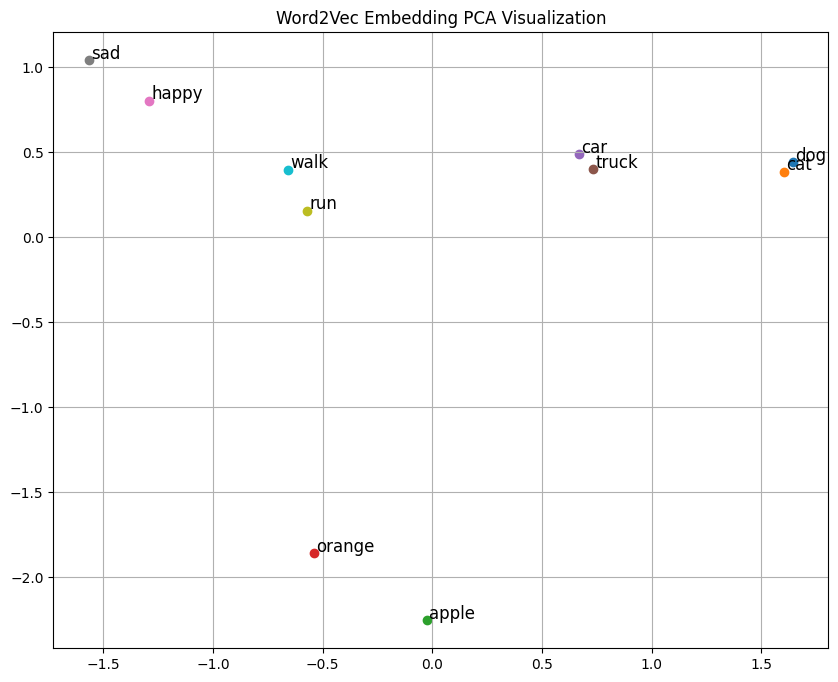

In [ ]:
# 라이브러리 import
import gensim.downloader as api
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. 사전 학습된 Word2Vec 모델 불러오기
model = api.load('word2vec-google-news-300')  # 300차원 벡터입니다

# 2. 단어 리스트 준비하기
words = ['dog', 'cat', 'apple', 'orange', 'car', 'truck', 'happy', 'sad', 'run', 'walk']

# 3. 단어에 해당하는 벡터 가져오기
word_vectors = np.array([model[word] for word in words])

# 4. PCA로 차원 축소 (300D -> 2D)

"""
TODO
"""

# 5. 시각화
plt.figure(figsize=(10,8))
for i, word in enumerate(words):
    x, y = word_vecs_2d[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word, fontsize=12)

plt.title('Word2Vec Embedding PCA Visualization')
plt.grid(True)
plt.show()

# Q10:
 N-Gram 언어 모델에서는 다음에 나올 단어가 이전 n개의 단어를 참조해서 만들어지는 것이라고 배웠습니다. 이를 활용하여 word2vec embedding을 구현해보려고 합니다.

(1) 아래 N_Gram_Embed 클래스의 __init__ 함수에는 사용할 word embedding layer와 일반적인 fully connected layer가 사용됩니다. 아래 조건에 맞추어 embedding layer 및 fully connected layer를 만들어 주세요.
- Embedding layer의 input dimension은 size_vocab이고, output dimension은 dim_embedding
- 첫 번째 fully connected layer의 output dimension은 hidden_size
- 두 번째 fully connected layer의 output dimension은 size_vocab

(2) N_Gram_Embed 클래스의 forward propagation 함수를 만들어 주세요. 아래 조건들을 사용합니다.
- forward 함수에는 한 번에 한 개의 데이터셋만 받도록 합니다 (즉, minibatch를 사용하지 않고 stochastic gradient descent를 사용합니다)
- 첫 번째 fully connected layer에는 relu activation을 부여합니다
- forward propagation의 결과로 output에 대한 softmax의 log probability를 리턴합니다.

참고로, 아래 Text를 활용하여 Embedding을 진행합니다.
===
The expression of his face as he said these words was not at all pleasant, and I had my own reasons for thinking that the stranger was mistaken, even supposing he meant what he said. But it was no affair of mine, I thought; and besides, it was difficult to know what to do. The stranger kept hanging about just inside the inn door, peering round the corner like a cat waiting for a mouse. Once I stepped out myself into the road, but he immediately called me back, and as I did not obey quick enough for his fancy, a most horrible change came over his tallowy face, and he ordered me in with an oath that made me jump. As soon as I was back again he returned to his former manner, half fawning, half sneering, patted me on the shoulder, told me I was a good boy and he had taken quite a fancy to me. I have a son of my own, said he, as like you as two blocks, and he's all the pride of my 'art. But the great thing for boys is discipline, sonny--discipline. Now, if you had sailed along of Bill, you wouldn't have stood there to be spoke to twice--not you. That was never Bill's way, nor the way of sich as sailed with him. And here, sure enough, is my mate Bill, with a spy-glass under his arm, bless his old 'art, to be sure. You and me'll just go back into the parlour, sonny, and get behind the door, and we'll give Bill a little surprise—bless his 'art, I say again.
(출처: R. L. Stevenson, Treasure Island)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import LongTensor as LT
size_context = 3
dim_embedding = 10
num_epoch = 60
test_sentence = """The expression of his face as he said these words was not at all pleasant, and I had my own reasons for thinking that the stranger was mistaken, even supposing he meant what he said. But it was no affair of mine, I thought; and besides, it was difficult to know what to do. The stranger kept hanging about just inside the inn door, peering round the corner like a cat waiting for a mouse. Once I stepped out myself into the road, but he immediately called me back, and as I did not obey quick enough for his fancy, a most horrible change came over his tallowy face, and he ordered me in with an oath that made me jump. As soon as I was back again he returned to his former manner, half fawning, half sneering, patted me on the shoulder, told me I was a good boy and he had taken quite a fancy to me. I have a son of my own, said he, as like you as two blocks, and he's all the pride of my 'art. But the great thing for boys is discipline, sonny--discipline. Now, if you had sailed along of Bill, you wouldn't have stood there to be spoke to twice--not you. That was never Bill's way, nor the way of sich as sailed with him. And here, sure enough, is my mate Bill, with a spy-glass under his arm, bless his old 'art, to be sure. You and me'll just go back into the parlour, sonny, and get behind the door, and we'll give Bill a little surprise—bless his 'art, I say again.""".split()
ngram = [([test_sentence[i-j-1] for j in range(size_context)],test_sentence[i]) for i in range(size_context, len(test_sentence))]
print(ngram[:5])

vocab = set(test_sentence)
word_to_ix = {word: i for i, word in enumerate(vocab)}
print(word_to_ix)

class N_Gram_Embed(nn.Module):
    def __init__(self, size_vocab, dim_embedding, size_context, hidden_size = 64):
        super(N_Gram_Embed, self).__init__()
        """
        TODO
        """
    def forward(self, inputs):
        """
        TODO
        """
        return log_prob
loss_cul = []
loss_func = nn.NLLLoss()
model = N_Gram_Embed(len(vocab), dim_embedding, size_context)
optimizer = optim.SGD(model.parameters(), lr=1e-3)
for epoch in range(num_epoch):
    loss_epoch = 0
    for context, target in ngram:
        context_idx = LT([word_to_ix[w] for w in context])
        model.zero_grad()
        loss = loss_func(model.forward(context_idx), LT([word_to_ix[target]]))
        loss.backward()
        optimizer.step()
        loss_epoch += loss.item()
    loss_cul.append(loss_epoch)
    print("Epoch:",epoch,"Loss:",loss_epoch)
#TEST
print(model.embed.weight[word_to_ix["expression"]])

[(['of', 'expression', 'The'], 'his'), (['his', 'of', 'expression'], 'face'), (['face', 'his', 'of'], 'as'), (['as', 'face', 'his'], 'he'), (['he', 'as', 'face'], 'said')]
{'on': 0, 'great': 1, 'little': 2, 'mouse.': 3, 'I': 4, 'own': 5, 'even': 6, 'an': 7, 'go': 8, 'just': 9, 'sneering,': 10, 'stranger': 11, 'over': 12, 'know': 13, 'way': 14, 'sailed': 15, 'what': 16, 'half': 17, 'back': 18, 'bless': 19, "'art.": 20, 'own,': 21, 'quick': 22, 'spy-glass': 23, 'not': 24, 'most': 25, 'road,': 26, 'did': 27, 'Bill,': 28, 'face,': 29, 'me': 30, 'fancy': 31, 'into': 32, 'boy': 33, 'old': 34, 'you.': 35, 'came': 36, 'in': 37, 'door,': 38, 'change': 39, 'stood': 40, 'for': 41, 'sure': 42, 'had': 43, 'expression': 44, 'of': 45, 'meant': 46, 'You': 47, 'tallowy': 48, 'soon': 49, 'it': 50, 'that': 51, 'stepped': 52, 'me.': 53, 'he,': 54, 'waiting': 55, 'under': 56, 'his': 57, 'taken': 58, 'all': 59, 'made': 60, 'inside': 61, 'son': 62, 'if': 63, 'peering': 64, 'enough': 65, 'That': 66, 'blocks,'

10-2. CBOW를 직접 embedding layer와 fully connected layer로 구성해서 학습해 보도록 합니다.위에서 동일한 텍스트를 활용합니다.

(1) n-Gram language에서는 context 벡터를 구성할 때 현재 단어 뒤의 n개 단어만 고려했었습니다. 하지만 CBOW의 경우는 앞뒤 단어를 모두 고려해야 하기 때문에, 앞서 구성했던 n-Gram의 컨텍스트 벡터 ngram에서 조금 변화를 주어야 합니다. 이 부분을 채워 보세요.

(2) 앞의 1번 문제에서와 같이 클래스 CBOW의 뉴럴 네트워크 레이어와 forward 함수를 적어 주세요.
* HINT: forward 함수는 n-Gram의 것과 동일하게 작성해도 됩니다.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import LongTensor as LT
size_context = 3
dim_embedding = 10
num_epoch = 60
test_sentence = """The expression of his face as he said these words was not at all pleasant, and I had my own reasons for thinking that the stranger was mistaken, even supposing he meant what he said. But it was no affair of mine, I thought; and besides, it was difficult to know what to do. The stranger kept hanging about just inside the inn door, peering round the corner like a cat waiting for a mouse. Once I stepped out myself into the road, but he immediately called me back, and as I did not obey quick enough for his fancy, a most horrible change came over his tallowy face, and he ordered me in with an oath that made me jump. As soon as I was back again he returned to his former manner, half fawning, half sneering, patted me on the shoulder, told me I was a good boy and he had taken quite a fancy to me. I have a son of my own, said he, as like you as two blocks, and he's all the pride of my 'art. But the great thing for boys is discipline, sonny--discipline. Now, if you had sailed along of Bill, you wouldn't have stood there to be spoke to twice--not you. That was never Bill's way, nor the way of sich as sailed with him. And here, sure enough, is my mate Bill, with a spy-glass under his arm, bless his old 'art, to be sure. You and me'll just go back into the parlour, sonny, and get behind the door, and we'll give Bill a little surprise—bless his 'art, I say again.""".split()
vocab = set(test_sentence)
size_vocab = len(vocab)
word_to_ix = {word: i for i, word in enumerate(vocab)}
data = []
for i in range(size_context, len(test_sentence) - size_context):
    near = #TODO
    target = test_sentence[i]
    data.append((near, target))
print(data[:3])

class CBOW(nn.Module):
    def __init__(self, size_vocab, dim_embedding, size_context, hidden_size = 64):
        super(CBOW, self).__init__()

        #TODO

    def forward(self, inputs):

        #TODO

        return log_prob
loss_cul = []
loss_func = nn.NLLLoss()
model = CBOW(len(vocab), dim_embedding, size_context)
optimizer = optim.SGD(model.parameters(), lr=1e-3)
for epoch in range(num_epoch):
    loss_epoch = 0
    for context, target in data:
        context_idx = LT([word_to_ix[w] for w in context])
        model.zero_grad()
        loss = loss_func(model.forward(context_idx), LT([word_to_ix[target]]))
        loss.backward()
        optimizer.step()
        loss_epoch += loss.item()
    loss_cul.append(loss_epoch)
    print("Epoch:",epoch,"Loss:",loss_epoch)
#TEST
print(model.embed.weight[word_to_ix["expression"]])

[(['of', 'expression', 'The', 'face', 'as', 'he'], 'his'), (['his', 'of', 'expression', 'as', 'he', 'said'], 'face'), (['face', 'his', 'of', 'he', 'said', 'these'], 'as')]
Epoch: 0 Loss: 1378.228660583496
Epoch: 1 Loss: 1371.9202771186829
Epoch: 2 Loss: 1365.715470790863
Epoch: 3 Loss: 1359.5875701904297
Epoch: 4 Loss: 1353.5225586891174
Epoch: 5 Loss: 1347.4985585212708
Epoch: 6 Loss: 1341.521985054016
Epoch: 7 Loss: 1335.5770931243896
Epoch: 8 Loss: 1329.6521606445312
Epoch: 9 Loss: 1323.7266631126404
Epoch: 10 Loss: 1317.7883665561676
Epoch: 11 Loss: 1311.8557841777802
Epoch: 12 Loss: 1305.9067676067352
Epoch: 13 Loss: 1299.9266345500946
Epoch: 14 Loss: 1293.9138555526733
Epoch: 15 Loss: 1287.8557720184326
Epoch: 16 Loss: 1281.7475097179413
Epoch: 17 Loss: 1275.590062379837
Epoch: 18 Loss: 1269.3902502059937
Epoch: 19 Loss: 1263.136631011963
Epoch: 20 Loss: 1256.8031122684479
Epoch: 21 Loss: 1250.3994364738464
Epoch: 22 Loss: 1243.9222836494446
Epoch: 23 Loss: 1237.3771493434906
Epo